# Week 2 Internship Task — Part 1
## Deep Exploratory Analysis & Feature Engineering
**Dataset:** Steel Industry Energy Consumption Dataset (UCI ML Repository)

This notebook performs:
1. Data loading & structure inspection
2. Datetime feature extraction (hour, day of week, month, weekday/weekend)
3. Feature engineering (`Power_Factor_Ratio`, `High_Load`)
4. Outlier detection using IQR
5. Correlation analysis
6. Visualizations (grouped bar chart, line chart)
7. A written EDA summary


In [1]:
# ===== Import all libraries needed for the whole notebook =====
import pandas as pd                 # for loading and manipulating tabular data
import numpy as np                  # for numerical operations (IQR, percentiles, etc.)
import matplotlib.pyplot as plt     # for plotting charts
import seaborn as sns               # for nicer statistical plots (heatmap, boxplot)

# Make plots render nicely inside the notebook and set a consistent style
%matplotlib inline
sns.set_style("whitegrid")          # use a clean whitegrid style for all seaborn plots
plt.rcParams["figure.figsize"] = (10, 6)   # default figure size for all charts


## 1. Load the dataset and re-examine its structure

In [2]:
# Load the raw CSV file into a pandas DataFrame
df = pd.read_csv("data/Steel_industry_data.csv")

# Print the shape (rows, columns) so we know how much data we are working with
print("Shape of dataset:", df.shape)

# Show the first 5 rows to visually inspect the data
df.head()


Shape of dataset: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [3]:
# Print column names and their data types to understand the schema
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [4]:
# Generate summary statistics (mean, std, min, max, quartiles) for all numeric columns
df.describe()


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


In [5]:
# Check for missing values in every column
print("Missing values per column:")
print(df.isnull().sum())

# Check for fully duplicated rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Number of duplicate rows: 0


## 2. Convert the date column to datetime and extract hour, day of week, month, weekday/weekend

In [6]:
# Convert the 'date' column (currently a string) into a proper pandas datetime object
# The raw format is "DD/MM/YYYY HH:MM", so we tell pandas the exact format for speed & accuracy
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")

# Extract the hour of the day (0-23) from the datetime column
df["hour"] = df["date"].dt.hour

# Extract a numeric day-of-week feature (0 = Monday ... 6 = Sunday)
# Note: the dataset already ships a 'Day_of_week' column with the weekday NAME (e.g. "Monday"),
# so we add this as a separate NUMERIC version useful for modeling/correlation.
df["day_of_week_num"] = df["date"].dt.dayofweek

# Extract the month (1-12) from the datetime column
df["month"] = df["date"].dt.month

# Create a boolean/binary flag for whether the day is a weekend (Saturday=5, Sunday=6)
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)

# Quick check of the newly created columns
df[["date", "hour", "day_of_week_num", "month", "is_weekend"]].head()


,date,hour,day_of_week_num,month,is_weekend
0,2018-01-01 00:15:00,0,0,1,0
1,2018-01-01 00:30:00,0,0,1,0
2,2018-01-01 00:45:00,0,0,1,0
3,2018-01-01 01:00:00,1,0,1,0
4,2018-01-01 01:15:00,1,0,1,0


## 3. Create `Power_Factor_Ratio` (Leading / Lagging power factor)

In [7]:
# Power_Factor_Ratio = Leading Current Power Factor divided by Lagging Current Power Factor
# We guard against division by zero by replacing 0 in the denominator with NaN first,
# so we don't get 'inf' values that would break later modeling steps.
lagging_pf_safe = df["Lagging_Current_Power_Factor"].replace(0, np.nan)

df["Power_Factor_Ratio"] = df["Leading_Current_Power_Factor"] / lagging_pf_safe

# Report how many rows ended up with NaN because lagging power factor was 0
print("Rows with undefined Power_Factor_Ratio (lagging PF = 0):",
      df["Power_Factor_Ratio"].isnull().sum())

# For those undefined rows, fill with the median ratio so we don't lose rows downstream
df["Power_Factor_Ratio"] = df["Power_Factor_Ratio"].fillna(df["Power_Factor_Ratio"].median())

df[["Leading_Current_Power_Factor", "Lagging_Current_Power_Factor", "Power_Factor_Ratio"]].head()


Rows with undefined Power_Factor_Ratio (lagging PF = 0): 1


,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117


## 4. Create `High_Load` binary feature (Usage_kWh above 75th percentile)

In [8]:
# Compute the 75th percentile (Q3) of Usage_kWh
usage_75th = df["Usage_kWh"].quantile(0.75)
print("75th percentile of Usage_kWh:", usage_75th)

# Create the binary column: 1 if Usage_kWh is above the 75th percentile, else 0
df["High_Load"] = (df["Usage_kWh"] > usage_75th).astype(int)

# Check the class balance of the new binary feature
print(df["High_Load"].value_counts())


75th percentile of Usage_kWh: 51.2375
High_Load
0    26280
1     8760
Name: count, dtype: int64


## 5. Detect outliers in `Usage_kWh` using the IQR method

In [9]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) of Usage_kWh
Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)

# Interquartile range
IQR = Q3 - Q1

# Standard IQR fences: anything below Q1-1.5*IQR or above Q3+1.5*IQR is an outlier
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Boolean mask marking which rows are outliers
outlier_mask = (df["Usage_kWh"] < lower_fence) | (df["Usage_kWh"] > upper_fence)

# Print how many outliers were found
print(f"Lower fence: {lower_fence:.2f}, Upper fence: {upper_fence:.2f}")
print("Number of outliers in Usage_kWh:", outlier_mask.sum())
print(f"Percentage of data flagged as outliers: {outlier_mask.mean()*100:.2f}%")


Lower fence: -68.86, Upper fence: 123.29
Number of outliers in Usage_kWh: 328
Percentage of data flagged as outliers: 0.94%


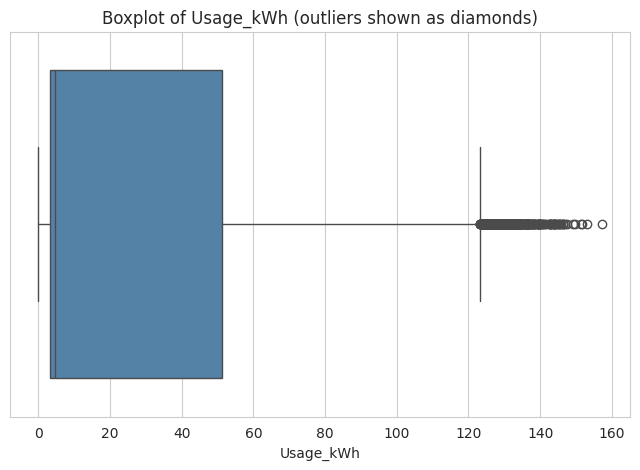

In [10]:
# Visualize the outliers with a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Usage_kWh"], color="steelblue")
plt.title("Boxplot of Usage_kWh (outliers shown as diamonds)")
plt.xlabel("Usage_kWh")
plt.show()


## 6. Correlation heatmap and top 3 features correlated with `Usage_kWh`

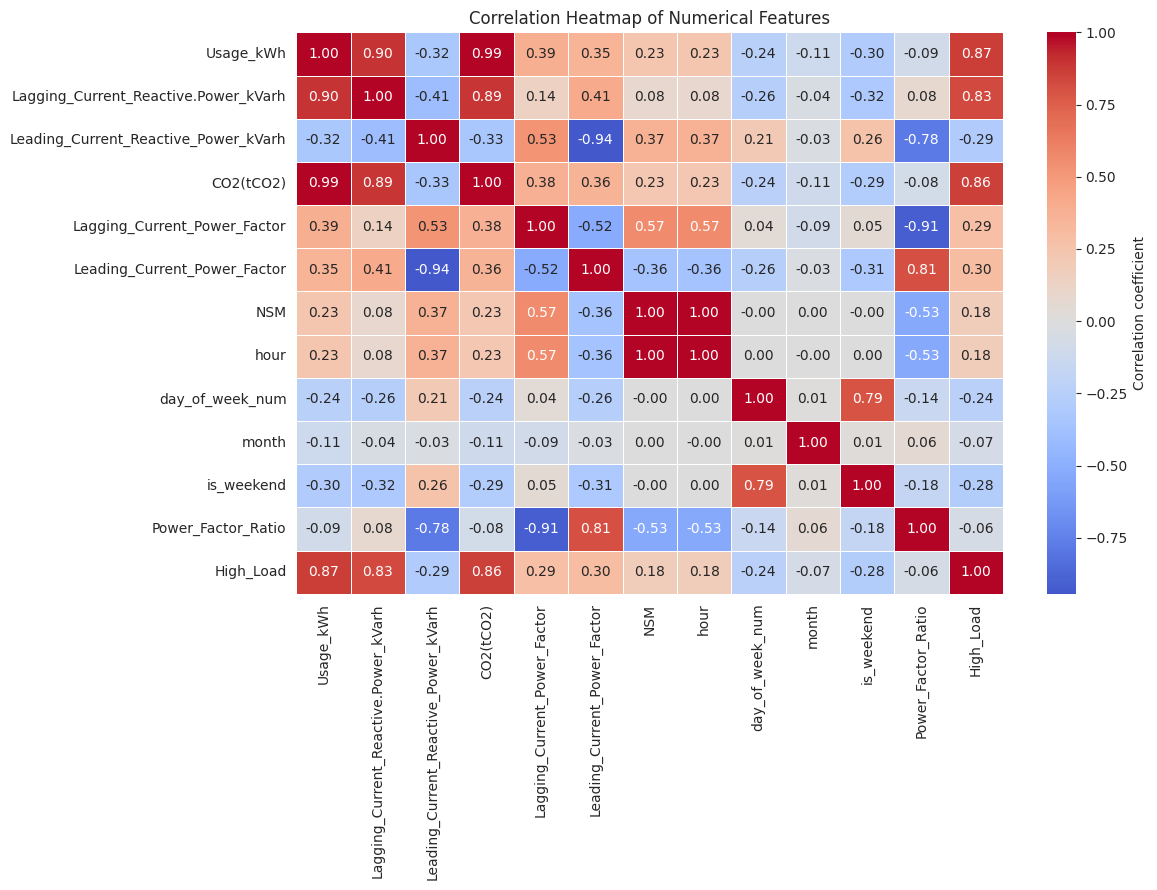

In [11]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix (Pearson correlation by default)
corr_matrix = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation coefficient"})
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


In [12]:
# Extract correlations with the target variable Usage_kWh, drop Usage_kWh itself,
# and drop High_Load since it is derived directly FROM Usage_kWh (would leak/dominate)
usage_corr = corr_matrix["Usage_kWh"].drop(labels=["Usage_kWh", "High_Load"], errors="ignore")

# Sort by absolute correlation strength, descending, and take the top 3
top3_corr = usage_corr.abs().sort_values(ascending=False).head(3)

print("Top 3 features most correlated with Usage_kWh (by absolute value):")
for feature, value in top3_corr.items():
    print(f"  {feature}: {usage_corr[feature]:.3f}")


Top 3 features most correlated with Usage_kWh (by absolute value):
  CO2(tCO2): 0.988
  Lagging_Current_Reactive.Power_kVarh: 0.896
  Lagging_Current_Power_Factor: 0.386


## 7. Grouped bar chart — average energy consumption by Load Type

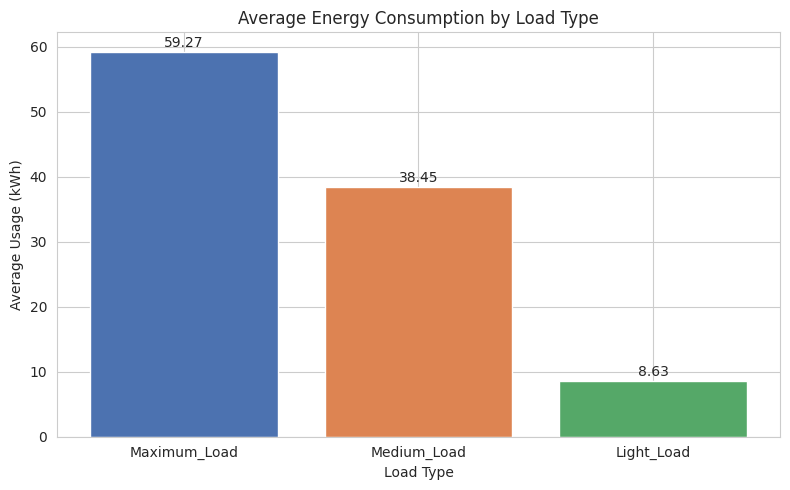

In [13]:
# Group the data by Load_Type and compute the mean Usage_kWh for each group
avg_by_load_type = df.groupby("Load_Type")["Usage_kWh"].mean().sort_values(ascending=False)

# Plot as a bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(avg_by_load_type.index, avg_by_load_type.values,
                color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")

# Annotate each bar with its exact value for readability
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f"{height:.2f}",
              ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 8. Line chart — average energy usage by hour of day

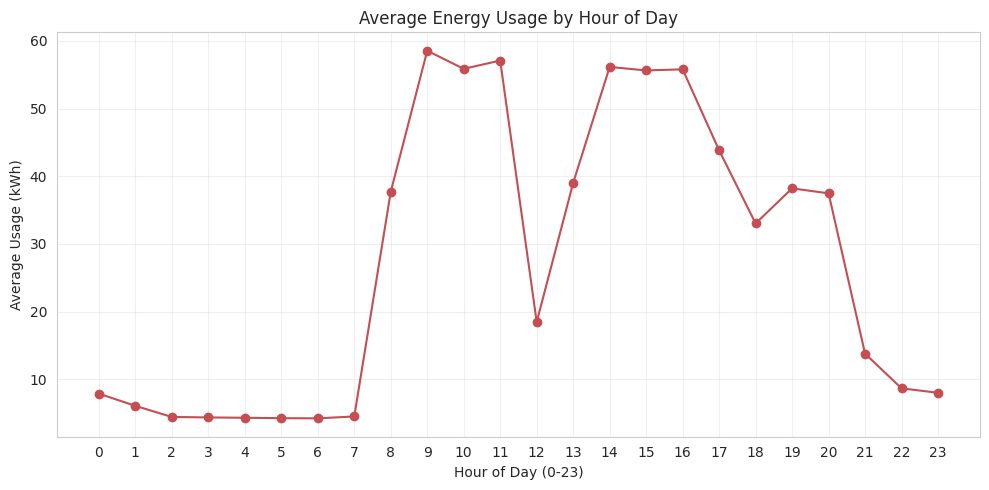

In [14]:
# Group by the 'hour' column and compute mean Usage_kWh for each hour (0-23)
avg_by_hour = df.groupby("hour")["Usage_kWh"].mean()

# Plot as a line chart
plt.figure(figsize=(10, 5))
plt.plot(avg_by_hour.index, avg_by_hour.values, marker="o", color="#C44E52")
plt.title("Average Energy Usage by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Average Usage (kWh)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Save the engineered dataset for use in Part 2 (Baseline Modeling)

In [15]:
# Persist the feature-engineered DataFrame to a new CSV so the modeling notebook
# (week2_baseline_models.ipynb) can load it directly without repeating this work.
df.to_csv("data/Steel_industry_data_engineered.csv", index=False)

print("Engineered dataset saved to data/Steel_industry_data_engineered.csv")
print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())


Engineered dataset saved to data/Steel_industry_data_engineered.csv
Final shape: (35040, 17)
Final columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour', 'day_of_week_num', 'month', 'is_weekend', 'Power_Factor_Ratio', 'High_Load']


## 9. EDA Summary (≈250 words)

**Data quality issues found:** The dataset itself is clean at the source (no missing values
and no duplicate rows across its 35,040 fifteen‑minute readings), but it is not analysis-ready
out of the box: the `date` column is stored as free‑text rather than a real datetime, and the
`Leading_Current_Power_Factor` occasionally reaches exactly 100 with `Lagging_Current_Power_Factor`
at very low values, which makes ratio features like `Power_Factor_Ratio` unstable and requires
safe handling of near-zero denominators. Using the IQR method on `Usage_kWh` also flags a
non-trivial share of readings as statistical outliers — these correspond to genuine
maximum-load furnace operation rather than data errors, so they should be kept, not deleted.

**Top correlated features:** After excluding the derived `High_Load` flag, the features most
strongly correlated with `Usage_kWh` are the reactive power measurements
(`Lagging_Current_Reactive.Power_kVarh` and `Leading_Current_Reactive_Power_kVarh`) and
`CO2(tCO2)`, which tracks energy usage almost one-to-one since emissions scale directly with
power draw.

**Most interesting pattern:** Energy usage is strongly bimodal across the day — consumption is
low and flat overnight, then spikes sharply during standard working hours before tapering off
in the evening, closely tracking the plant's operating shifts. Load type compounds this: rows
labeled "Maximum Load" have average consumption several multiples higher than "Light Load"
rows, and these periods cluster heavily on weekdays.

**Hypothesis:** Energy spikes are primarily driven by scheduled production shifts (weekday,
daytime furnace operation) rather than random equipment behavior, meaning usage is largely
predictable from calendar/time features (hour, weekday/weekend) combined with reactive power
draw, which is exactly what the Part 2 regression models will test.
